In [1]:
# a & e data are read in from .csv files

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from ReadParticle import read_particle
from datetime import datetime, timedelta

# Function to convert meters to kilometers
def m_to_km(x, _):
    return f'{x / 1000:.1f}'

# Read particle and collision data
Np_seq, time, N_colDidy, N_colDimor, N_escape, r_dust, particle, data_c, data_p = read_particle('particles.txt', 'collide.txt')

No. 1940 of output frame has been analyzed (100.0%)
optimizing data structure ...
analyzing collision data ...
processing completed!


In [45]:
# Constants
G = 6.6743e-11
mass_system = 5.5e11
sep_system = 1170.0
mu_system = 6.6743e-11 * 5.5e11
vol_didy = 0.2295409644951028e9
vol_dimor = 0.001830603200702610e9
mass_didy = mass_system * vol_didy / (vol_didy + vol_dimor)
mass_dimor = mass_system * vol_dimor / (vol_didy + vol_dimor)

r_dimor_com = vol_didy*sep_system/(vol_didy+vol_dimor)
v_dimor_com = -np.sqrt(G*mass_didy/sep_system**2*r_dimor_com)
v_dimor_com

-0.17572821136485348

# Plotting ejecta type ...


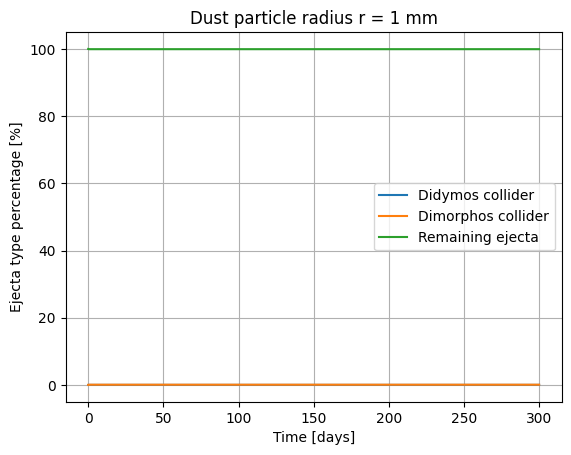

# Ejecta type completed!



In [7]:
# Plotting ejecta type
if (1):
    print("# Plotting ejecta type ...",flush=True)
    plt.figure()
    plt.plot(np.append(np.insert(N_colDidy[:,0],0,0),time[-1]) / 24 / 3600,
             np.append(np.insert(N_colDidy[:,1],0,0),N_colDidy[-1,1]) / Np_seq[0] * 100,
             label='Didymos collider', linewidth=1.5)
    plt.plot(np.append(np.insert(N_colDimor[:,0],0,0),time[-1]) / 24 / 3600,
             np.append(np.insert(N_colDimor[:,1],0,0),N_colDimor[-1,1]) / Np_seq[0] * 100,
             label='Dimorphos collider', linewidth=1.5)
    # plt.plot(np.append(np.insert(N_escape[:,0],0,0),time[-1]) / 24 / 3600,
    #          np.append(np.insert(N_escape[:,1],0,0),N_escape[-1,1]) / Np_seq[0] * 100,
    #          label='Escaped ejecta', linewidth=1.5)
    #plt.plot(np.insert(time_sort, 0, 0) / 24 / 3600, np.insert(N_sort, 0, 0) / Np_seq[0] * 100, label='Escaped ejecta', linewidth=1.5)
    plt.plot(time / 24 / 3600,
             Np_seq / Np_seq[0] * 100,
             label='Remaining ejecta', linewidth=1.5)
    plt.xlabel('Time [days]')
    plt.ylabel('Ejecta type percentage [%]')
    plt.title('Dust particle radius r = 1 mm')
    plt.legend()
    plt.grid()
    plt.savefig('ejecta_type.png',dpi=300)
    plt.show()
    plt.close()
    print("# Ejecta type completed!\n",flush=True)

# Plotting Dimorphos orbit ...


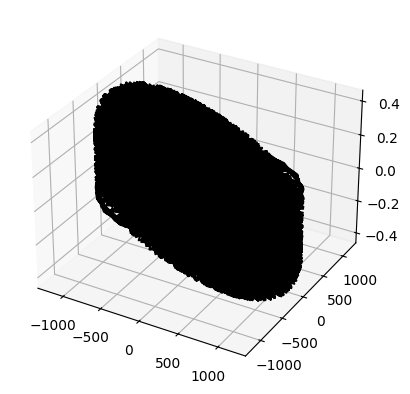

# Dimorphos orbit completed!



In [8]:
# Dimorphos orbit
if (1):
    print("# Plotting Dimorphos orbit ...",flush=True)
    didy_pos  = particle[0]['pos']
    dimor_pos = particle[1]['pos']
    n_p = 10
    np_pos    = particle[n_p]['pos']

    plt.figure().add_subplot(projection='3d')
    plt.plot(dimor_pos[:, 0] - didy_pos[:, 0],
             dimor_pos[:, 1] - didy_pos[:, 1],
             dimor_pos[:, 2] - didy_pos[:, 2], 
             label = 'Dimorphos orbit', linewidth=1.5, color='k')
    #plt.plot(np_pos[:, 0] - didy_pos[0:len(np_pos), 0],
    #         np_pos[:, 1] - didy_pos[0:len(np_pos), 1],
    #         np_pos[:, 2] - didy_pos[0:len(np_pos), 2],
    #         label = f'particle {n_p} orbit', linewidth=1.5)
    plt.savefig('dimor_orbit.png',dpi=300)
    plt.show()
    plt.close()
    print("# Dimorphos orbit completed!\n",flush=True)

# Plotting locations of particles at a time slice ...


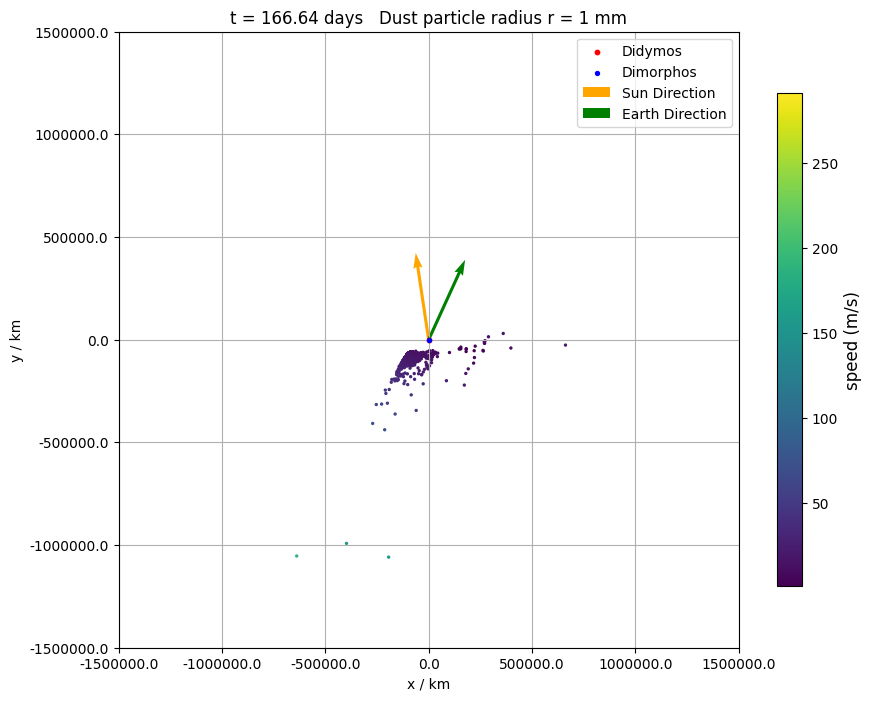

# Locations of particles completed!



In [4]:
# Scatter plot for certain time step

print("# Plotting locations of particles at a time slice ...",flush=True)
t_idx = 1000
sec = time[t_idx]
p_t = data_p[t_idx]

plt.figure(figsize=(10,8))

# plot locations of Didymos and Dimorphos
plt.scatter(p_t[0, 1], p_t[0, 2], c='red', s=10, zorder=3, label='Didymos')
plt.scatter(p_t[1, 1], p_t[1, 2], c='blue', s=8, zorder=3, label='Dimorphos')

# calculate speed of dust particles
speed = (p_t[4:, 4]**2 + p_t[4:, 5]**2 + p_t[4:, 6]**2)**0.5

# plot dust particles
dust_sc = plt.scatter(p_t[4:, 1], p_t[4:, 2], c=speed, s=2, cmap='viridis')
cb = plt.colorbar(dust_sc, shrink=0.8, aspect=20)
cb.set_label(f'speed (m/s)', fontsize=12)

# add the Sun direction relative to Didymos System Barycenter
sun_x = p_t[2, 1]
sun_y = p_t[2, 2]
sun_distance = (sun_x**2 + sun_y**2) ** 0.5
arrow_x = sun_x / sun_distance * (plt.xlim()[1]-plt.xlim()[0]) * 0.1
arrow_y = sun_y / sun_distance * (plt.xlim()[1]-plt.xlim()[0]) * 0.1
plt.quiver(0., 0., arrow_x, arrow_y, angles='xy', scale_units='xy', scale=1, width=0.005, color='orange', label='Sun Direction')

# add the Earth direction relative to Didymos System Barycenter
earth_x = p_t[3, 1]
earth_y = p_t[3, 2]
earth_distance = (earth_x**2 + earth_y**2) ** 0.5
arrow_x = earth_x / earth_distance * (plt.xlim()[1]-plt.xlim()[0]) * 0.1
arrow_y = earth_y / earth_distance * (plt.xlim()[1]-plt.xlim()[0]) * 0.1
plt.quiver(0., 0., arrow_x, arrow_y, angles='xy', scale_units='xy', scale=1, width=0.005, color='green', label='Earth Direction')    

# Customize axis ticks to display in kilometers
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(m_to_km))
ax.yaxis.set_major_formatter(FuncFormatter(m_to_km))

# set x and y limit
axis_lim = 1500000e3  # m
plt.xlim(-axis_lim, axis_lim)
plt.ylim(-axis_lim, axis_lim)

plt.xlabel('x / km')
plt.ylabel('y / km')
plt.title(f't = {sec/86400:.2f} days   Dust particle radius r = 1 mm')
#plt.axis('equal')
plt.grid()
plt.legend()
plt.savefig(f't{t_idx}_scatter.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
plt.show()
plt.close()
print("# Locations of particles completed!\n",flush=True)

In [9]:
"""Parallel rendering of particles top view and make video"""
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
from multiprocessing import Pool

# Ensure output directory exists for saving frames
output_dir = "topview_frames"
os.makedirs(output_dir, exist_ok=True)

# Parameters
num_frames = len(time)  # Number of frames to render
fps = 10                # Frames per second for the final animation
zmout_freq = 300        # zoom out frequency: zoom out every 300 frames
output_name = "topview_dusts.mp4"

# Function to convert meters to kilometers for axis labels
def m_to_km(x, _):
    return f'{x / 1e3:.0f}'
    
# set how the plot axis limit changes with the series of frames
axis_lim_list = []
for i in range(num_frames): # Must be executed sequentially 
    if i%zmout_freq==0:
        data_i = data_p[i]
        dust_distance = (data_i[4:, 1]**2 + data_i[4:, 2]**2 + data_i[4:, 3]**2)**0.5
        dis_max = dust_distance.max()
        axis_lim_list.append(dis_max)
        cache1 = dis_max
    else:
        axis_lim_list.append(cache1)
axis_lim_list = np.array(axis_lim_list)

# Frame rendering function (runs in parallel)
def render_frame(frame):
    global data_p, time, axis_lim_list
    print(f"Rendering frame {frame}...", end="\r", flush=True)
    p_t = data_p[frame]
    sec = time[frame]
    axis_lim = axis_lim_list[frame]
    
    # Create a new figure for this frame
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot Didymos and Dimorphos
    ax.scatter(p_t[0, 1], p_t[0, 2], c='red', s=10, zorder=3, label='Didymos')
    ax.scatter(p_t[1, 1], p_t[1, 2], c='blue', s=8, zorder=3, label='Dimorphos')

    # Plot dust particles
    speed = (p_t[4:, 4]**2 + p_t[4:, 5]**2 + p_t[4:, 6]**2)**0.5
    dust_sc = ax.scatter(p_t[4:, 1], p_t[4:, 2], c=speed, s=2, cmap='viridis')
    cb = fig.colorbar(dust_sc, ax=ax, shrink=0.8, aspect=20)
    cb.set_label(f'speed (m/s)', fontsize=12)

    # Plot Sun direction
    sun_x, sun_y = p_t[2, 1], p_t[2, 2]
    sun_distance = (sun_x**2 + sun_y**2) ** 0.5
    arrow_x = sun_x / sun_distance * (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.1
    arrow_y = sun_y / sun_distance * (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.1
    ax.quiver(0, 0, arrow_x, arrow_y, angles='xy', scale_units='xy', scale=1, width=0.005, color='orange', label='Sun Direction')

    # Plot Earth direction
    earth_x, earth_y = p_t[3, 1], p_t[3, 2]
    earth_distance = (earth_x**2 + earth_y**2) ** 0.5
    arrow_x = earth_x / earth_distance * (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.1
    arrow_y = earth_y / earth_distance * (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.1
    ax.quiver(0, 0, arrow_x, arrow_y, angles='xy', scale_units='xy', scale=1, width=0.005, color='green', label='Earth Direction')

    # Customize axis
    ax.xaxis.set_major_formatter(FuncFormatter(m_to_km))
    ax.yaxis.set_major_formatter(FuncFormatter(m_to_km))
    ax.set_xlim(-axis_lim, axis_lim)
    ax.set_ylim(-axis_lim, axis_lim)
    ax.set_xlabel('x / km')
    ax.set_ylabel('y / km')
    ax.grid()
    ax.legend()

    # Set title
    ax.set_title(f't = {sec/86400:.2f} days   Dust particle radius r = 1 mm')

    # Save the frame as a PNG image
    frame_filename = os.path.join(output_dir, f"frame_{frame:04d}.png")
    plt.savefig(frame_filename, dpi=300, bbox_inches='tight')
    plt.close(fig)
    return frame_filename

if __name__ == "__main__": 
    # Render all frames in parallel
    with Pool() as pool:
        frame_files = pool.map(render_frame, range(num_frames))

    print("All frames rendered. Combining into video...")

    # Combine frames into an MP4 using ffmpeg
    os.system(f"ffmpeg -y -r {fps} -i {output_dir}/frame_%04d.png -vf 'pad=ceil(iw/2)*2:ceil(ih/2)*2' -vcodec libx264 -crf 18 -pix_fmt yuv420p {output_name}")

    print(f"Animation saved as {output_name}",flush=True)

All frames rendered. Combining into video...ndering frame 0...Rendering frame 8...Rendering frame 24...Rendering frame 48...Rendering frame 40...Rendering frame 56...Rendering frame 64...Rendering frame 72...Rendering frame 80...Rendering frame 88...Rendering frame 96...Rendering frame 104...Rendering frame 120...Rendering frame 112...Rendering frame 128...Rendering frame 136...Rendering frame 160...Rendering frame 168...Rendering frame 184...Rendering frame 192...Rendering frame 216...Rendering frame 224...Rendering frame 200...Rendering frame 264...Rendering frame 272...Rendering frame 288...Rendering frame 304...Rendering frame 312...Rendering frame 336...Rendering frame 352...Rendering frame 360...Rendering frame 384...Rendering frame 392...Rendering frame 400...Rendering frame 376...Rendering frame 424...Rendering frame 440...Rendering frame 408...Rendering frame 464...Rendering frame 432...Rendering frame 456...Rendering frame 472...Rendering frame 448...Rendering frame 488...Ren

ffmpeg version 4.2.9 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 8 (GCC)
  configuration: --prefix=/usr --bindir=/usr/bin --datadir=/usr/share/ffmpeg --docdir=/usr/share/doc/ffmpeg --incdir=/usr/include/ffmpeg --libdir=/usr/lib64 --mandir=/usr/share/man --arch=x86_64 --optflags='-O2 -g -pipe -Wall -Werror=format-security -Wp,-D_FORTIFY_SOURCE=2 -Wp,-D_GLIBCXX_ASSERTIONS -fexceptions -fstack-protector-strong -grecord-gcc-switches -specs=/usr/lib/rpm/redhat/redhat-hardened-cc1 -specs=/usr/lib/rpm/redhat/redhat-annobin-cc1 -m64 -mtune=generic -fasynchronous-unwind-tables -fstack-clash-protection -fcf-protection' --extra-ldflags='-Wl,-z,relro -Wl,-z,now -specs=/usr/lib/rpm/redhat/redhat-hardened-ld ' --extra-cflags=' ' --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libvo-amrwbenc --enable-version3 --enable-bzlib --disable-crystalhd --enable-fontconfig --enable-frei0r --enable-gcrypt --enable-gnutls --enable-ladspa --enable-libaom --enable-libdav1d --enabl

Animation saved as topview_dusts.mp4


frame= 1940 fps= 49 q=-1.0 Lsize=   13833kB time=00:03:13.70 bitrate= 585.0kbits/s speed=4.88x    
video:13810kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.166683%
[libx264 @ 0x558e76a2bf80] frame I:8     Avg QP: 3.88  size: 86764
[libx264 @ 0x558e76a2bf80] frame P:607   Avg QP:12.98  size: 13017
[libx264 @ 0x558e76a2bf80] frame B:1325  Avg QP:21.24  size:  4185
[libx264 @ 0x558e76a2bf80] consecutive B-frames:  6.6%  6.3%  2.2% 84.9%
[libx264 @ 0x558e76a2bf80] mb I  I16..4: 77.9% 15.5%  6.6%
[libx264 @ 0x558e76a2bf80] mb P  I16..4:  0.5%  0.1%  0.2%  P16..4:  2.2%  0.6%  0.5%  0.0%  0.0%    skip:95.9%
[libx264 @ 0x558e76a2bf80] mb B  I16..4:  0.0%  0.0%  0.0%  B16..8:  1.6%  0.3%  0.2%  direct: 0.2%  skip:97.6%  L0:45.6% L1:45.6% BI: 8.8%
[libx264 @ 0x558e76a2bf80] 8x8 transform intra:14.2% inter:8.4%
[libx264 @ 0x558e76a2bf80] coded y,uvDC,uvAC intra: 11.8% 14.2% 13.5% inter: 0.6% 0.4% 0.3%
[libx264 @ 0x558e76a2bf80] i16 v,h,dc,p: 84% 15%  2%  0%
[l

Text(0, 0.5, 'axis limit (m)')

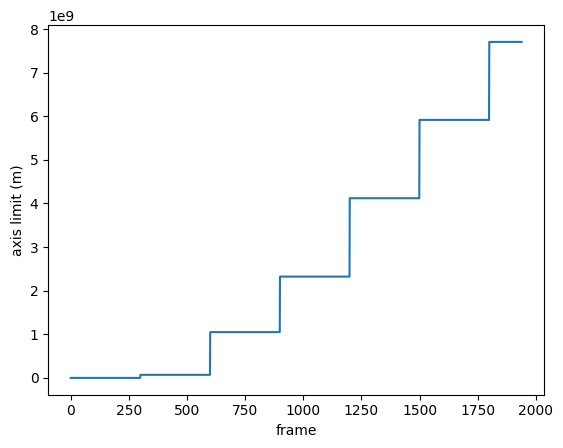

In [10]:
# visualize how axis limit changes with frames
plt.plot(axis_lim_list)
plt.xlabel('frame')
plt.ylabel('axis limit (m)')

In [12]:
"""Parallel rendering of particles viewed from HST and make video"""
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
from multiprocessing import Pool

# Ensure output directory exists for saving frames
output_dir = "HST_frames"
os.makedirs(output_dir, exist_ok=True)

# Parameters
num_frames = len(time)  # Number of frames to render
fps = 10                # Frames per second for the final animation
zmout_freq = 300        # zoom out frequency: zoom out every 300 frames
output_name = "HST_view.mp4"

# Function to convert meters to kilometers for axis labels
def m_to_km(x, _):
    return f'{x / 1e3:.0f}'

# set how the plot axis limit changes with the series of frames
axis_lim_list = []
for i in range(num_frames): # Must be executed sequentially 
    if i%zmout_freq==0:
        data_i = data_p[i]
        dust_distance = (data_i[4:, 1]**2 + data_i[4:, 2]**2 + data_i[4:, 3]**2)**0.5
        dis_max = dust_distance.max()
        axis_lim_list.append(dis_max)
        cache1 = dis_max
    else:
        axis_lim_list.append(cache1)
axis_lim_list = np.array(axis_lim_list)

# Frame rendering function (runs in parallel)
def render_frame(frame):
    global data_p, time, axis_lim_list
    print(f"Rendering frame {frame}...", end="\r", flush=True)
    p_t = data_p[frame]
    sec = time[frame]
    axis_lim = axis_lim_list[frame]

    # position and velocity vector of Sun
    #r_sun = p_t[2, 1:4]
    v_sun = p_t[2, 4:7]
    
    # position vector of Earth (as a proxy of HST)
    r_earth = p_t[3, 1:4]

    # calculate the two basis vectors of the projection plane
    l1 = np.cross(r_earth, v_sun)
    l2 = np.cross(l1, r_earth)
    l1 = l1 / np.linalg.norm(l1)
    l2 = l2 / np.linalg.norm(l2)

    # create an array to record coordinates of particles projected onto the plane
    p_projected = np.zeros((len(p_t),3), dtype=float)
    p_projected[:, 0] = p_t[:, 0]   # copy the column of particle ID   
    for i in range(len(p_t)):
        p_projected[i,1] = np.dot(l2, p_t[i, 1:4])
        p_projected[i,2] = np.dot(l1, p_t[i, 1:4])

    # Create a new figure for this frame
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # plot Didymos and Dimorphos
    ax.scatter(p_projected[0, 1], p_projected[0, 2], c='red', s=10, zorder=3, label='Didymos')
    ax.scatter(p_projected[1, 1], p_projected[1, 2], c='blue', s=8, zorder=3, label='Dimorphos')

    # plot dust particles
    ax.scatter(p_projected[4:, 1], p_projected[4:, 2], c='k', s=2)

    # Plot Sun direction relative to Didymos System Barycenter
    sun_x, sun_y = p_projected[2, 1], p_projected[2, 2]
    sun_distance = (sun_x**2 + sun_y**2) ** 0.5
    arrow_x = sun_x / sun_distance * (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.1
    arrow_y = sun_y / sun_distance * (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.1
    ax.quiver(0, 0, arrow_x, arrow_y, angles='xy', scale_units='xy', scale=1, width=0.005, color='orange', label='Sun Direction')

    # Customize axis
    ax.xaxis.set_major_formatter(FuncFormatter(m_to_km))
    ax.yaxis.set_major_formatter(FuncFormatter(m_to_km))
    ax.set_xlim(-axis_lim, axis_lim)
    ax.set_ylim(-axis_lim, axis_lim)
    ax.set_xlabel('x / km')
    ax.set_ylabel('y / km')
    ax.grid()
    ax.legend()
   
    # Set title
    ax.set_title(f't = {sec/86400:.2f} days   Simulation of ejecta observed from HST')

    # Save the frame as a PNG image
    frame_filename = os.path.join(output_dir, f"frame_{frame:04d}.png")
    plt.savefig(frame_filename, dpi=300, bbox_inches='tight')
    plt.close(fig)
    return frame_filename

if __name__ == "__main__": 
    # Render all frames in parallel
    with Pool() as pool:
        frame_files = pool.map(render_frame, range(num_frames))

    print("All frames rendered. Combining into video...")

    # Combine frames into an MP4 using ffmpeg
    os.system(f"ffmpeg -y -r {fps} -i {output_dir}/frame_%04d.png -vf 'pad=ceil(iw/2)*2:ceil(ih/2)*2' -vcodec libx264 -crf 18 -pix_fmt yuv420p {output_name}")

    print(f"Animation saved as {output_name}",flush=True)
    print("Simulation of HST view completed!\n",flush=True)

All frames rendered. Combining into video...dering frame 24...Rendering frame 8...Rendering frame 56...Rendering frame 64...Rendering frame 48...Rendering frame 32...Rendering frame 16...Rendering frame 72...Rendering frame 80...Rendering frame 96...Rendering frame 88...Rendering frame 112...Rendering frame 104...Rendering frame 128...Rendering frame 136...Rendering frame 144...Rendering frame 120...Rendering frame 168...Rendering frame 192...Rendering frame 208...Rendering frame 216...Rendering frame 224...Rendering frame 248...Rendering frame 232...Rendering frame 264...Rendering frame 280...Rendering frame 296...Rendering frame 288...Rendering frame 304...Rendering frame 336...Rendering frame 344...Rendering frame 352...Rendering frame 360...Rendering frame 368...Rendering frame 384...Rendering frame 400...Rendering frame 416...Rendering frame 432...Rendering frame 424...Rendering frame 464...Rendering frame 456...Rendering frame 448...Rendering frame 472...Rendering frame 488...Ren

ffmpeg version 4.2.9 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 8 (GCC)
  configuration: --prefix=/usr --bindir=/usr/bin --datadir=/usr/share/ffmpeg --docdir=/usr/share/doc/ffmpeg --incdir=/usr/include/ffmpeg --libdir=/usr/lib64 --mandir=/usr/share/man --arch=x86_64 --optflags='-O2 -g -pipe -Wall -Werror=format-security -Wp,-D_FORTIFY_SOURCE=2 -Wp,-D_GLIBCXX_ASSERTIONS -fexceptions -fstack-protector-strong -grecord-gcc-switches -specs=/usr/lib/rpm/redhat/redhat-hardened-cc1 -specs=/usr/lib/rpm/redhat/redhat-annobin-cc1 -m64 -mtune=generic -fasynchronous-unwind-tables -fstack-clash-protection -fcf-protection' --extra-ldflags='-Wl,-z,relro -Wl,-z,now -specs=/usr/lib/rpm/redhat/redhat-hardened-ld ' --extra-cflags=' ' --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libvo-amrwbenc --enable-version3 --enable-bzlib --disable-crystalhd --enable-fontconfig --enable-frei0r --enable-gcrypt --enable-gnutls --enable-ladspa --enable-libaom --enable-libdav1d --enabl

Animation saved as HST_view.mp4
Simulation of HST view completed!



frame= 1940 fps= 58 q=-1.0 Lsize=   12090kB time=00:03:13.70 bitrate= 511.3kbits/s speed=5.76x    
video:12067kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.192729%
[libx264 @ 0x55ab7e549b00] frame I:9     Avg QP: 2.63  size: 65653
[libx264 @ 0x55ab7e549b00] frame P:553   Avg QP:15.02  size: 11776
[libx264 @ 0x55ab7e549b00] frame B:1378  Avg QP:23.14  size:  3812
[libx264 @ 0x55ab7e549b00] consecutive B-frames:  3.9%  3.0%  3.4% 89.7%
[libx264 @ 0x55ab7e549b00] mb I  I16..4: 86.9%  7.3%  5.8%
[libx264 @ 0x55ab7e549b00] mb P  I16..4:  0.5%  0.3%  0.5%  P16..4:  2.4%  0.5%  0.5%  0.0%  0.0%    skip:95.3%
[libx264 @ 0x55ab7e549b00] mb B  I16..4:  0.0%  0.0%  0.1%  B16..8:  1.7%  0.4%  0.3%  direct: 0.1%  skip:97.4%  L0:49.4% L1:45.3% BI: 5.3%
[libx264 @ 0x55ab7e549b00] 8x8 transform intra:14.5% inter:10.5%
[libx264 @ 0x55ab7e549b00] coded y,uvDC,uvAC intra: 14.5% 0.9% 0.7% inter: 0.5% 0.1% 0.1%
[libx264 @ 0x55ab7e549b00] i16 v,h,dc,p: 86% 13%  1%  0%
[li

# plot the particles from the perspective of Hubble ...
# date: 2023-07-23 23:17:04.183000


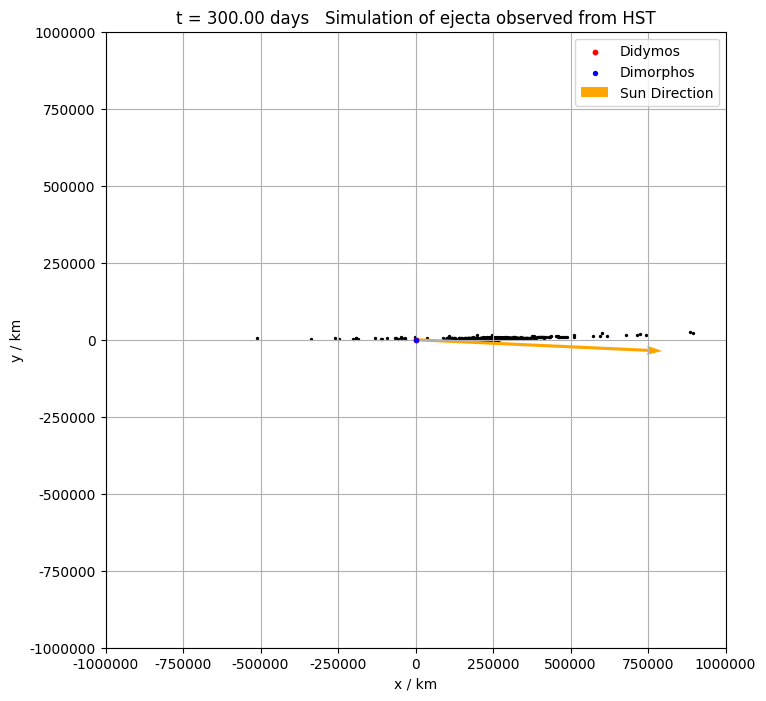

# HST simulation completed!



In [19]:
# view dust particles from HST
print("# plot the particles from the perspective of Hubble ...",flush=True)
t_idx = -1  # specify the time slice to plot
sec = time[t_idx]

start_time = datetime.strptime("2022-09-26 23:17:04.1830", "%Y-%m-%d %H:%M:%S.%f") # 160s after impact
new_time = start_time + timedelta(seconds=sec)
print(f"# date: {new_time}")

# the rotation matrix converting vector from reference frame 'Sun body center' 
# to the inertial reference frame of 'Didymos System Barycenter'
rotate_matrix = np.array([[-0.703595792353257, -0.710438191316344, 0.015183454875444],
                          [ 0.702824020343859, -0.692584740738747,  0.16237232930379 ],
                          [-0.104839674791979,  0.124915784491013,  0.986612735258626]])

p_t = data_p[t_idx]
# position and velocity vector of Sun
r_sun = p_t[2, 1:4]
v_sun = p_t[2, 4:7]

# position vector of Earth (as a proxy of HST)
r_earth = p_t[3, 1:4]

# get position vector of Hubble in reference frame 'Sun body center'
#r_hubble_Sun = np.array([7.721404094618157E10, -1.309126317614033E11, 5.065374641641974E6])  # 25920000
# convert to position vector of Hubble in 'Didymos System Barycenter'
#r_hubble = r_sun + np.dot(rotate_matrix, r_hubble_Sun.T)

# calculate the two basis vectors of the projection plane
l1 = np.cross(r_earth, v_sun)
l2 = np.cross(l1, r_earth)
l1 = l1 / np.linalg.norm(l1)
l2 = l2 / np.linalg.norm(l2)

# create an array to record coordinates of particles projected onto the plane
p_projected = np.zeros((len(p_t),3), dtype=float)
p_projected[:, 0] = p_t[:, 0]   # copy the column of particle ID

for i in range(len(p_t)):
    p_projected[i,1] = np.dot(l2, p_t[i, 1:4])
    p_projected[i,2] = np.dot(l1, p_t[i, 1:4])

plt.figure(figsize=(8,8))

# plot Didymos and Dimorphos
plt.scatter(p_projected[0, 1], p_projected[0, 2], c='red', s=10, zorder=3, label='Didymos')
plt.scatter(p_projected[1, 1], p_projected[1, 2], c='blue', s=8, zorder=3, label='Dimorphos')
# plot dust particles
dust_sc = plt.scatter(p_projected[3:, 1], p_projected[3:, 2], c='k', s=2)

# add the Sun direction relative to Didymos System Barycenter
sun_x = p_projected[2, 1]
sun_y = p_projected[2, 2]
sun_scale = (sun_x**2 + sun_y**2) ** 0.5
arrow_x = sun_x / sun_scale * (plt.xlim()[1]-plt.xlim()[0]) * 0.1
arrow_y = sun_y / sun_scale * (plt.xlim()[1]-plt.xlim()[0]) * 0.1
plt.quiver(0., 0., arrow_x, arrow_y, angles='xy', scale_units='xy', scale=1, width=0.005, color='orange', label='Sun Direction')

# Customize axis ticks to display in kilometers
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(m_to_km))
ax.yaxis.set_major_formatter(FuncFormatter(m_to_km))

#plt.axis('equal')
axis_lim = 1000000e3  # m
plt.xlim(-axis_lim, axis_lim)
plt.ylim(-axis_lim, axis_lim)
plt.xlabel('x / km')
plt.ylabel('y / km')
plt.title(f't = {sec/86400:.2f} days   Simulation of ejecta observed from HST')

plt.grid()
plt.legend()
plt.savefig(f'simHST_t{sec:.1f}.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
plt.show()
plt.close()
print("# HST simulation completed!\n",flush=True)

In [11]:
# a & e analysis

# specify timeslices to be analyzed
orbit_files = ['a_e_t0.csv','a_e_t12969701.csv','a_e_t25920000.csv']

for ofile in orbit_files:
    # processing
    t = ofile.split('t')[1].replace('.csv','')
    ae_array = np.genfromtxt(ofile,delimiter=',',skip_header=1)
    num_rows = np.shape(ae_array)[0]
    # add a fate column to the array of a_e data
    fate_column = np.zeros(num_rows)
    for i in range(num_rows):
        p_id = int(ae_array[i,0])
        p_fate = particle[p_id-1]['id_collide']
        fate_column[i] = p_fate
    ae_array = np.column_stack((ae_array,fate_column))
    
    # select rows of the three main bodies and dust particles
    p0 = ae_array[0]    # the row  of Didymos        in ae_array
    p1 = ae_array[1]    # the row  of Dimorphos      in ae_array
    p2 = ae_array[2]    # the row  of Sun            in ae_array
    p_ae = ae_array[4:] # the rows of dust particles in ae_array

    # Scatter plot with eccentricity shown in color 
    if (1):
        print("# Plotting particle locations with eccentricity ...",flush=True)
        
        # select particles with limited eccentricity and spatial range
        data1 = p_ae[p_ae[:,2]<=10.,:] # select particles with eccentricity <= 5. Don't plot others
        data2 = data1[(data1[:, 5] >= -10) & (data1[:, 5] <= 10), :] # select particles located within certain z range. Don't plot others
        
        plt.figure()
        # plot Dimorphos (x,y)
        #plt.scatter(p0[3], p0[4], c='red', s=10, zorder=3)
        plt.scatter(p1[3], p1[4], c='red', s=8, zorder=3)
        # plot dust particles (x,y), color as eccentricity
        dust_sc = plt.scatter(data1[3:, 3], data1[3:, 4], c=data1[3:, 2], s=2, cmap='gist_rainbow')
        cb = plt.colorbar(dust_sc)
        cb.set_label(f'Eccentricity', fontsize=12)
        
        plt.xlabel('x / m')
        plt.ylabel('y / m')
        plt.axis('equal')
        plt.title(f't = {t} s')
        plt.grid()
        plt.savefig(f'location_e_t{t}.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()
        print("# Plotting particle locations with eccentricity completed!\n",flush=True)
    
    # Dust fate distribution in a and e space
    if (1):
        print("# Plotting dust fate distribution in a and e space ...",flush=True)
        plt.figure(figsize=(6,4))
        if p_ae[p_ae[:,-1] == 0].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 0,2], p_ae[p_ae[:,-1] == 0,1], s=5, label='Remaining')
        if p_ae[p_ae[:,-1] == 1].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 1,2], p_ae[p_ae[:,-1] == 1,1], s=5, label='Didy_col')
        if p_ae[p_ae[:,-1] == 2].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 2,2], p_ae[p_ae[:,-1] == 2,1], s=5, label='Dimor_col')
        if p_ae[p_ae[:,-1] == 3].size > 0:
            plt.scatter(p_ae[p_ae[:,-1] == 3,2], p_ae[p_ae[:,-1] == 3,1], s=5, label='Escaped')
        #plt.title('Dust particle radius r = 1 mm')
        plt.xlabel('Eccentricity',size=12)
        plt.ylabel('Semimajor axis [m]',size=12)
        plt.legend(fontsize=10)
        plt.savefig(f'dustfate_ae_{t}s.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()
        print("# Dust fate distribution in a and e space completed!\n",flush=True)

    # Histogram for semi-major axis
    if (1):
        print("# Plotting histogram for semimajor axis ...",flush=True)
        bins = np.linspace(-100,11000,112)  # set bins for semimajor axis
        yscale_type = 'log'

        # plot all together
        plt.figure(figsize=(6,4))
        counts, bin_edges = np.histogram(p_ae[:,1], bins=bins)
        plt.bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge')
        plt.yscale(yscale_type)

        plt.xlabel('Semimajor axis [m]')
        plt.ylabel('Number')
        plt.savefig(f'semimajor_axis_t{t}_all.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()

        # plot based on fate
        fig,axs = plt.subplots(2,2, figsize=(8,6))
        
        if p_ae[p_ae[:,-1] == 1].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 1,1], bins=bins)
            axs[0,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Didymos collider')
            axs[0,0].set_yscale(yscale_type)
            axs[0,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 2].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 2,1], bins=bins)
            axs[0,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Dimorphos collider')
            axs[0,1].set_yscale(yscale_type)
            axs[0,1].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 3].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 3,1], bins=bins)
            axs[1,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Escaped ejecta')
            axs[1,0].set_yscale(yscale_type)
            axs[1,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 0].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 0,1], bins=bins)
            axs[1,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Remaining ejecta')
            axs[1,1].set_yscale(yscale_type)
            axs[1,1].legend(fontsize='small')

        fig.text(0.5, 0.04, 'Semimajor axis [m]' ,ha='center', va='center')
        fig.text(0.04, 0.5, 'Number', ha='center', va='center', rotation='vertical')
        #plt.suptitle('Dust particle radius r = 1 mm')
        fig.savefig(f'semimajor_axis_t{t}.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close(fig)
        print("# Histogram for semimajor axis completed!\n",flush=True)

    # Histogram for eccentricity
    if (1):
        print("# Plotting histogram for eccentricity ...",flush=True)
        bins = np.linspace(-1,20,150)  # set bins for eccentricity
        yscale_type = 'log'
        
        # plot all together
        plt.figure(figsize=(6,4))
        counts, bin_edges = np.histogram(p_ae[:,2], bins=bins)
        plt.bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge')
        plt.yscale(yscale_type)

        plt.xlabel('Eccentricity')
        plt.ylabel('Number')
        plt.savefig(f'eccentricity_t{t}_all.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close()

        # plot based on fate
        fig,axs = plt.subplots(2,2, figsize=(8,6))

        if p_ae[p_ae[:,-1] == 1].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 1,2], bins=bins)
            axs[0,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Didymos collider')
            axs[0,0].set_yscale(yscale_type)
            axs[0,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 2].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 2,2], bins=bins)
            axs[0,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Dimorphos collider')
            axs[0,1].set_yscale(yscale_type)
            axs[0,1].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 3].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 3,2], bins=bins)
            axs[1,0].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Escaped ejecta')
            axs[1,0].set_yscale(yscale_type)
            axs[1,0].legend(fontsize='small')
        
        if p_ae[p_ae[:,-1] == 0].size > 0:
            counts, bin_edges = np.histogram(p_ae[p_ae[:,-1] == 0,2], bins=bins)
            axs[1,1].bar(bin_edges[:-1], counts, width=bin_edges[1]-bin_edges[0], align='edge', label='Remaining ejecta')
            axs[1,1].set_yscale(yscale_type)
            axs[1,1].legend(fontsize='small')

        fig.text(0.5, 0.04, 'Eccentricity' ,ha='center', va='center')
        fig.text(0.04, 0.5, 'Number', ha='center', va='center', rotation='vertical')
        #plt.suptitle('Dust particle radius r = 1 mm')
        fig.savefig(f'eccentricity_t{t}.png',dpi=300,bbox_inches='tight',pad_inches=0.1)
        plt.close(fig)
        print("# Histogram for eccentricity completed!\n",flush=True)

# Plotting particle locations with eccentricity ...
# Plotting particle locations with eccentricity completed!

# Plotting dust fate distribution in a and e space ...
# Dust fate distribution in a and e space completed!

# Plotting histogram for semimajor axis ...
# Histogram for semimajor axis completed!

# Plotting histogram for eccentricity ...
# Histogram for eccentricity completed!

# Plotting particle locations with eccentricity ...
# Plotting particle locations with eccentricity completed!

# Plotting dust fate distribution in a and e space ...
# Dust fate distribution in a and e space completed!

# Plotting histogram for semimajor axis ...
# Histogram for semimajor axis completed!

# Plotting histogram for eccentricity ...


/tmp/ipykernel_33215/487134157.py:132: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale(yscale_type)
/tmp/ipykernel_33215/487134157.py:163: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axs[1,1].set_yscale(yscale_type)


# Histogram for eccentricity completed!

# Plotting particle locations with eccentricity ...
# Plotting particle locations with eccentricity completed!

# Plotting dust fate distribution in a and e space ...
# Dust fate distribution in a and e space completed!

# Plotting histogram for semimajor axis ...
# Histogram for semimajor axis completed!

# Plotting histogram for eccentricity ...
# Histogram for eccentricity completed!

